In [3]:
#my leaening on langchagenrative ai agenst s llms steop by step  

In [4]:
1+1

2

In [24]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")


In [25]:
#importing langchain library that creates agents and tools for llms 
from langchain.agents import create_agent

In [26]:
#temperature is zero means the model will always give the same answer for the same question, 
# while a higher temperature will make the output more random and creative.

In [54]:
# verbose=True tells LangChain:
#“Show me everything happening internally
agent1 = create_agent("gpt-3.5-turbo",
                     tools=[],
                     system_prompt="You are a helpful assistant that can answer questions and perform tasks.",
                     )

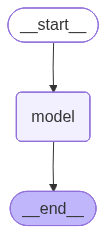

In [55]:
agent1
#actually we have created an agent
#  but there are no tools specified and 
# attached to the llm so it is now basically an llm, normal llm 
# but we can use it as an agent and attach tools to it and make it more powerful and useful for us

In [40]:
#sample function  for now it is our tool lets us say we want to create a tool that can do some basic math calculations
def calculator(question):
    # this is a simple calculator function that can evaluate basic math expressions
    """calculate this expression""" 
    try:
        return eval(question)
    except Exception as e:
        return str(e)
    


agent = create_agent("gpt-3.5-turbo",
                     tools=[calculator],
                     system_prompt="You are a helpful assistant that can answer questions and perform tasks.",
                    )

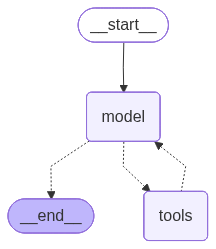

In [34]:
agent

In [42]:
#run the agent with the question and it will use the calculator tool to evaluate the expression and give us the answer
agent.invoke("calculate 312*23?")
# this wont runn becuase 
# we have not specified the tool name in the question 
# so it will not know which tool to use to answer the question
# we have to specify all these in dictionary format



InvalidUpdateError: Expected dict, got calculate 312*23?
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE

In [43]:
agent.invoke({"tool": "calculator", "input": "calculate 312*23?"})

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 50, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Db9qcv0uf3PypAMoH8iE0ywPbt16s', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dea0f-4179-7cf3-b0e3-6830c8e4b2bf-0', tool_calls=[{'name': 'calculator', 'args': {'question': '(3 + 5) * 6 + 4 / 2'}, 'id': 'call_kaEQVlBNMrrc6H059BhgAvsE', 'type': 'tool_call'}, {'name': 'calculator', 'args': {'question': '2 * (4 + 7) - 5'}, 'id': 'call_EI46JlrqrcF15Ha9WmMNviYt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 50, 'output_tokens': 67, 't

In [44]:
agent.invoke({"role": "user", "content": "calculate 312*23?"})

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 50, 'total_tokens': 112, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Db9qxHQpGlDl5dvmMM3SxYMunZv5L', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dea0f-9204-7c92-8789-cd2af2de53bc-0', tool_calls=[{'name': 'calculator', 'args': {'question': '5 * (3 + 7)'}, 'id': 'call_hmyA3RXuYzSKIXwjdKJJMmJx', 'type': 'tool_call'}, {'name': 'calculator', 'args': {'question': '(10 - 3) / (4 + 1)'}, 'id': 'call_Dioj1HT7VFppAU72ch6UuwLv', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 50, 'output_tokens': 62, 'total_

In [53]:
response = agent.invoke({"tool": "calculator", "input": "What is 312*23?"})
print(response["messages"][-1].content)   

The result of the expression "2 + 3 * 4" is 14.


In [ ]:
agent.run("What is the capital of France?", temperature=0)

AttributeError: 'CompiledStateGraph' object has no attribute 'run'